## Urban Infrastucture

## Business Understanding:
The objective of this project was to develop machine learning models that predict whether infrastructure failure will occur in a monitored city block. The prediction is binary (0 = no failure, 1 = failure).

Three classification algorithms were compared: logistic regression, decision tree, and neural network. The aim was to identify the model that best predicts failure risk using environmental, structural, and operational features.

In [204]:
# Import libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Data Understanding:

The dataset `urbandata.csv` contains observations for individual city blocks during monitoring windows. Each row represents a block and the associated environmental, structural, and operational measurements.

Initial exploration of the dataset included:

- Inspecting the structure of the data using `head()` and `info()`
- Checking for missing values using `isna()`
- Examining the distributions of numeric variables using histograms

These steps help identify potential data quality issues and provide an overview of the variables before model development.

   inspector_id  material_flexibility  structural_mass_ratio  \
0             5             31.762605              12.891996   
1             7             30.770158              11.835563   
2             6             31.591296              11.738267   
3             5             30.834649              11.622881   
4             2             33.315981              12.616065   

   recent_precipitation  infrastructure_age  surface_debris  \
0              4.711064           71.480592        9.429642   
1              3.315888           60.300892        8.655641   
2              2.425562           56.367965        9.017137   
3              2.164486           53.135138        8.864650   
4              4.557082           77.482269        9.549344   

   vibration_exposure  asset_density inspection_season inspection_window  \
0            5.177088         2.9944            summer         afternoon   
1            4.927622         2.6808            spring           morning   
2       

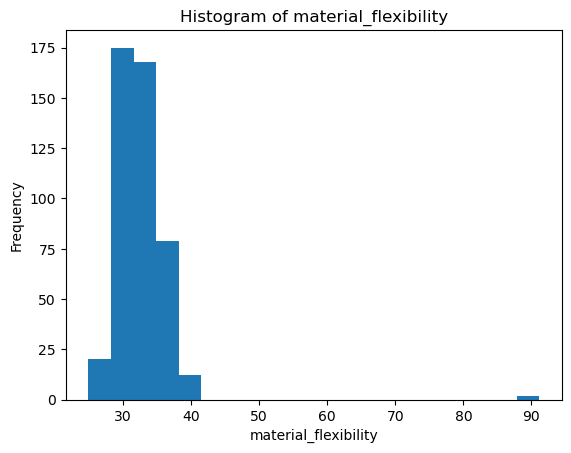

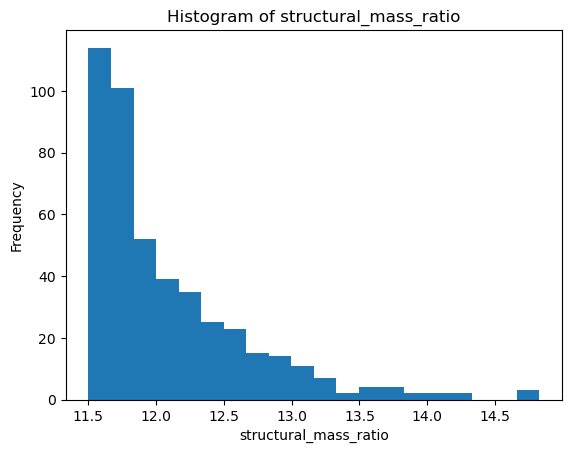

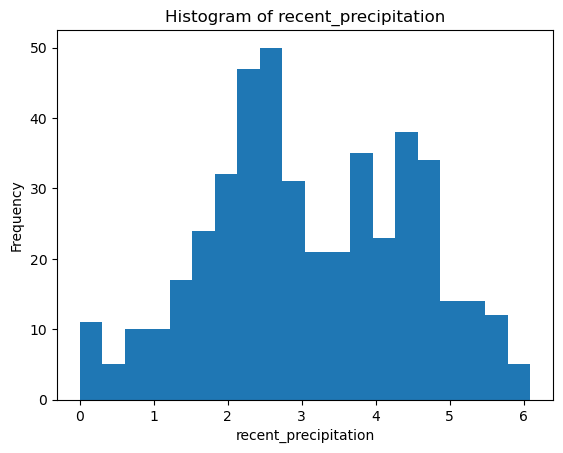

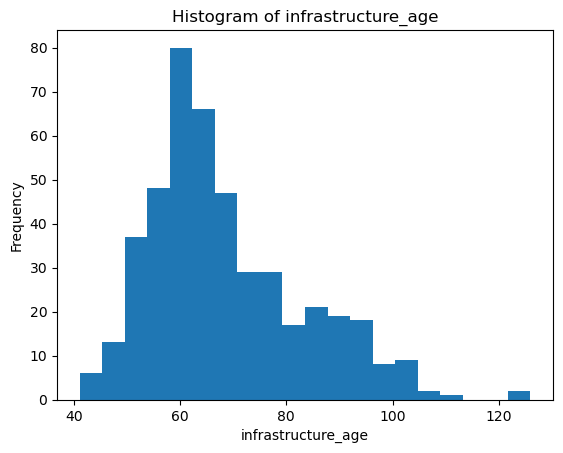

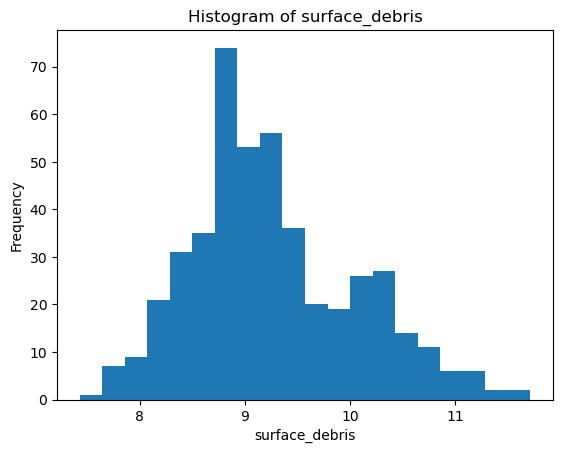

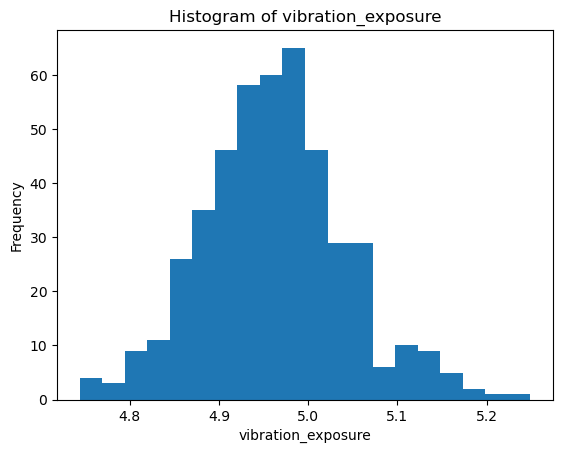

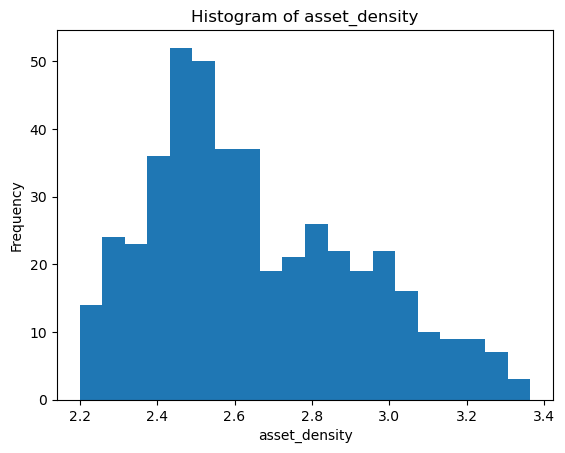

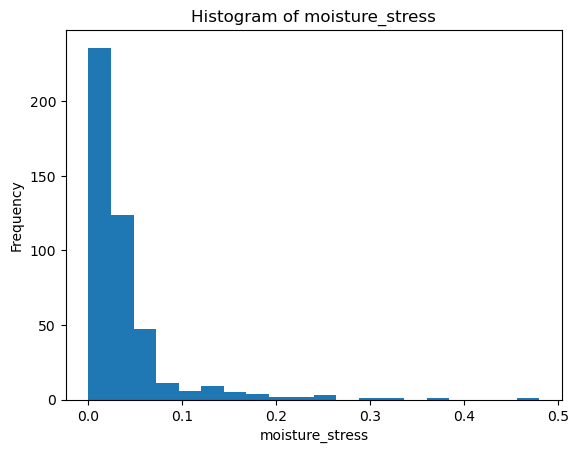

inspector_id             0
material_flexibility     0
structural_mass_ratio    1
recent_precipitation     2
infrastructure_age       4
surface_debris           0
vibration_exposure       1
asset_density            0
inspection_season        0
inspection_window        0
moisture_stress          3
failure                  0
dtype: int64
11


In [205]:
# Load in the data
data = pd.read_csv("urbandata.csv")

# View data
print(data.head())
print(data.info())

# Create Histograms for visualisation 
numeric_cols = [
    "material_flexibility",
    "structural_mass_ratio",
    "recent_precipitation",
    "infrastructure_age",
    "surface_debris",
    "vibration_exposure",
    "asset_density",
    "moisture_stress"
]

for col in numeric_cols:
    plt.figure()
    plt.hist(data[col].dropna(), bins=20)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {col}")
    plt.show()

# Check for missing data in each column
print(data.isna().sum())

# Get the total number of missing values in the entire dataset
print(data.isna().sum().sum())

## Data Cleaning

Histograms of the numeric variables were used to identify potential errors in the dataset.

The histogram for `infrastructure_age` revealed an extreme value that was far outside the range of the other observations. This suggested a likely data entry or recording error.

To correct this issue, observations with unrealistic values were removed:

`infrastructure_age < 900`

Rows containing missing values were also removed using `dropna()` so that the models would be trained only on complete records.

In [206]:
# Fixing the outlier in the infrastructure age that was identified in the histogram
data = data[data['infrastructure_age'] < 900]

# Handle the missing values identified
data = data.dropna()

## Feature Preparation

The target variable for the models is `failure`.

The variable `inspector_id` was removed from the predictors because it is an identifier rather than a meaningful feature for prediction.

Categorical variables (`inspection_season` and `inspection_window`) were converted into numerical features using one-hot encoding with `pd.get_dummies()`.

Numeric features were standardised using `StandardScaler` when training logistic regression and neural network models. Standardisation ensures that features are on comparable scales and improves the performance of models that are sensitive to feature magnitudes.

In [207]:
# Now that 'data' is clean, we separate them
X = data.drop(columns=["failure", "inspector_id"])
y = data["failure"]

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

Categorical variables (inspection_season and inspection_window) were converted using one-hot encoding so that the models can process them as numerical inputs. This allows the model to estimate separate effects for each category rather than assuming a numeric ordering between categories.

In [208]:
variable_table = pd.DataFrame({
    "Variable Used": [
        "material_flexibility",
        "structural_mass_ratio",
        "recent_precipitation",
        "infrastructure_age",
        "surface_debris",
        "vibration_exposure",
        "asset_density",
        "moisture_stress",
        "inspection_season",
        "inspection_window"
    ],
    
    "Model Treatment": [
        "Numeric (continuous)",
        "Numeric (continuous)",
        "Numeric (continuous)",
        "Numeric (continuous)",
        "Numeric (continuous)",
        "Numeric (continuous)",
        "Numeric (continuous)",
        "Numeric (continuous)",
        "Categorical (one-hot encoded)",
        "Categorical (one-hot encoded)"
    ]
})

variable_table

,Variable Used,Model Treatment
0,material_flexibility,Numeric (continuous)
1,structural_mass_ratio,Numeric (continuous)
2,recent_precipitation,Numeric (continuous)
3,infrastructure_age,Numeric (continuous)
4,surface_debris,Numeric (continuous)
5,vibration_exposure,Numeric (continuous)
6,asset_density,Numeric (continuous)
7,moisture_stress,Numeric (continuous)
8,inspection_season,Categorical (one-hot encoded)
9,inspection_window,Categorical (one-hot encoded)


## Train / Validation / Test Split

The dataset was divided into three subsets:

- Training set (60%)
- Validation set (20%)
- Test set (20%)

The training set is used to train the models.  
The validation set is used to compare models and select hyperparameters.  
The test set is used only once to evaluate the final chosen model.

This approach helps prevent overfitting and provides an unbiased estimate of model performance on unseen data.

In [209]:
# First split: 80% development, 20% test
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 75% train, 25% validation from development set
# This gives 60% train, 20% validation, 20% test overall
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, random_state=42, stratify=y_dev
)

# Scale using training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

Training set shape: (267, 15)
Validation set shape: (89, 15)
Test set shape: (89, 15)


## Models

Three classification models were trained:

**Logistic Regression**

A linear classification model that estimates the probability of failure using a logistic function.

**Decision Tree**

A tree-based model that splits the data based on feature thresholds in order to classify observations.

**Neural Network**

A multi-layer perceptron classifier that can capture nonlinear relationships between the predictors and the target variable.

In [210]:
# Logistic regression: 
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Train on training data
log_model.fit(X_train_scaled, y_train)

# Predict on validation data
pred_log_val = log_model.predict(X_val_scaled)

# Print validation accuracy
print("Logistic Regression Validation Accuracy:",
      accuracy_score(y_val, pred_log_val))

Logistic Regression Validation Accuracy: 0.9101123595505618


The logistic regression model initially produced a convergence warning. Increasing max_iter to 1000 allowed the optimisation algorithm to converge properly during training.

In [211]:
# Decision Tree:
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train on training data
tree_model.fit(X_train, y_train)

# Predict on validation data
pred_tree_val = tree_model.predict(X_val)

# Print validation accuracy
print("Decision Tree Validation Accuracy:",
      accuracy_score(y_val, pred_tree_val))

Decision Tree Validation Accuracy: 0.8876404494382022


In [212]:
# Neural Network:
nn_model = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=2000, random_state=42)

# Train on training data
nn_model.fit(X_train_scaled, y_train)

# Predict on validation data
pred_nn_val = nn_model.predict(X_val_scaled)

# Print validation accuracy
print("Neural Network Validation Accuracy:",
      accuracy_score(y_val, pred_nn_val))

Neural Network Validation Accuracy: 0.9101123595505618


## Model Comparison

The models were evaluated using validation accuracy.
Hyperparameter values were selected using the validation set and kept relatively simple to reduce the risk of overfitting.

In [213]:
# Save results of modelling into a table:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Neural Network"],
    
    "Metric": ["Accuracy", "Accuracy", "Accuracy"],
    
    "Score": [
        accuracy_score(y_val, pred_log_val),
        accuracy_score(y_val, pred_tree_val),
        accuracy_score(y_val, pred_nn_val)
    ],
    
    "Hyperparameters": [
        "max_iter=1000, random_state=42",
        "max_depth=5, random_state=42",
        "hidden_layer_sizes=(10,10), max_iter=2000, random_state=42"
    ]
})

results["Score"] = results["Score"].round(3)
results = results.sort_values("Score", ascending=False)
results.style\
    .hide(axis="index")\
    .set_caption("Model Comparison Results")\
    .set_table_styles([
        {"selector": "th", "props": [("font-size", "12pt"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center")]},
        {"selector": "caption", "props": [("font-size", "14pt"), ("font-weight", "bold")]}
    ])

Model,Metric,Score,Hyperparameters
Logistic Regression,Accuracy,0.910000,"max_iter=1000, random_state=42"
Neural Network,Accuracy,0.910000,"hidden_layer_sizes=(10,10), max_iter=2000, random_state=42"
Decision Tree,Accuracy,0.888000,"max_depth=5, random_state=42"


## Final Model Selection

Logistic regression was selected as the final model. It achieved the highest validation accuracy and performed similarly to the neural network while remaining simpler and easier to interpret.

## Confusion Matrix

The final logistic regression model was evaluated on the test set using a confusion matrix.

The confusion matrix shows the number of correct and incorrect predictions for both classes (failure and no failure). The results indicate that the model correctly identifies most cases of infrastructure failure as well as non-failure.

False negatives represent failures that the model did not predict, which are particularly important in this context because they correspond to unexpected infrastructure breakdowns.

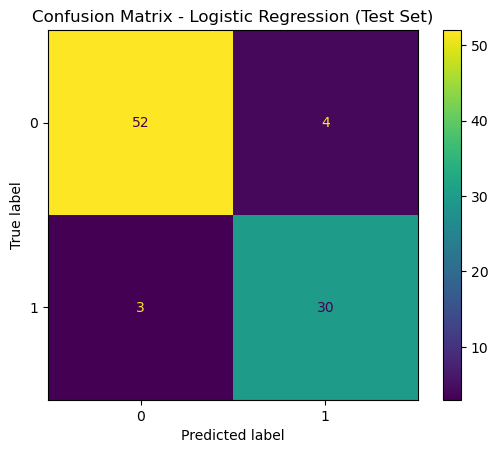

In [214]:
# Generate a confusion matrix for the final model

# Predict using the final model on the test set
pred_log_test = log_model.predict(X_test_scaled)

# Create confusion matrix
cm = confusion_matrix(y_test, pred_log_test)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Logistic Regression (Test Set)")
plt.show()

### Baseline Accuracy

A baseline model was created using a **most-frequent classifier**, which always predicts the most common class in the dataset. This provides a simple reference point for model performance.

The baseline accuracy was **{baseline_accuracy:.3f}**, meaning that a model which always predicts the majority class would achieve this level of accuracy.

All trained models achieved substantially higher accuracy than the baseline, indicating that the predictors contain useful information for identifying infrastructure failure risk.

In [217]:
# Checking to see if this is accurate by comparing against the baseline:
print("Shape after cleaning:", data.shape)
print(y.value_counts())
print(y.value_counts(normalize=True))

# Identify baseline accuracy
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
dummy_pred = dummy.predict(X_val)
accuracy_score(y_val, dummy_pred)
print("Baseline accuracy:", accuracy_score(y_test, dummy_pred))


Shape after cleaning: (445, 12)
failure
0    281
1    164
Name: count, dtype: int64
failure
0    0.631461
1    0.368539
Name: proportion, dtype: float64
Baseline accuracy: 0.6292134831460674
